<a href="https://colab.research.google.com/github/SergioGSF/programa-cultural-digital/blob/main/AtividadeEstatistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Aluno: Sergio Gonçalves da Silva Filho
#Turma: EMBARQUE DIGITA 2025.1 - Periodo: 3.
# 📊 Análise Exploratória de Dados (EDA)
## Dataset: Tips

**Objetivo:** Analisar padrões de consumo e gorjetas em um restaurante utilizando estatística descritiva.

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 🔍 1. Exploração Inicial

Analisando estrutura, tipos de dados e dimensões do dataset.

In [19]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


(244, 7)

O dataset possui 244 linhas e 7 colunas, sem valores nulos.

In [6]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


(244, 7)

O dataset possui 244 linhas e 7 colunas. Não há valores nulos. Existem variáveis numéricas e categóricas.




## 📊 2. Medidas Estatísticas

In [20]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


A média e mediana são próximas, indicando leve assimetria.

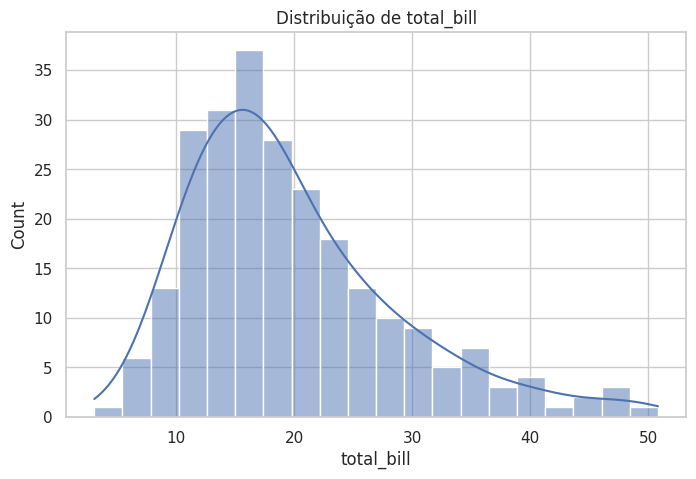

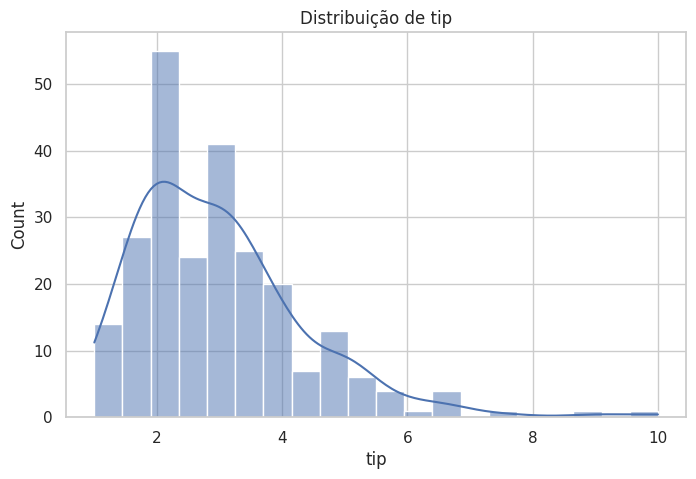

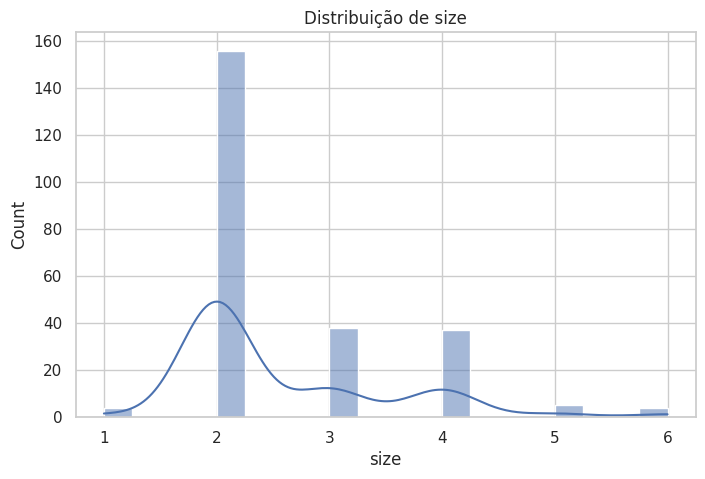

In [21]:
for col in ['total_bill', 'tip', 'size']:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f'Distribuição de {col}')
    plt.show()

## 📦 3. Quartis e Outliers

In [22]:
q1 = df['total_bill'].quantile(0.25)
q3 = df['total_bill'].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = df[(df['total_bill'] < lim_inf) | (df['total_bill'] > lim_sup)]

print("Outliers:", len(outliers))

Outliers: 9


Outliers representam contas muito acima da média.

## 📈 4. Distribuição

In [23]:
for col in ['total_bill', 'tip', 'size']:
    print(f"\n{col}")
    print("Skewness:", skew(df[col]))
    print("Kurtosis:", kurtosis(df[col]))


total_bill
Skewness: 1.1262346334818638
Kurtosis: 1.1691681323851366

tip
Skewness: 1.4564266884221506
Kurtosis: 3.5495519893455114

size
Skewness: 1.4389653841920984
Kurtosis: 1.6719276263625504


## 🔗 5. Correlação

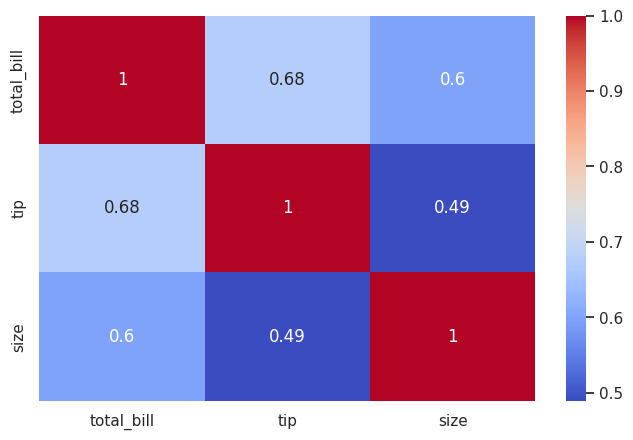

In [24]:
corr = df[['total_bill', 'tip', 'size']].corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Existe forte correlação entre total_bill e tip.

## 📦 6. Boxplots

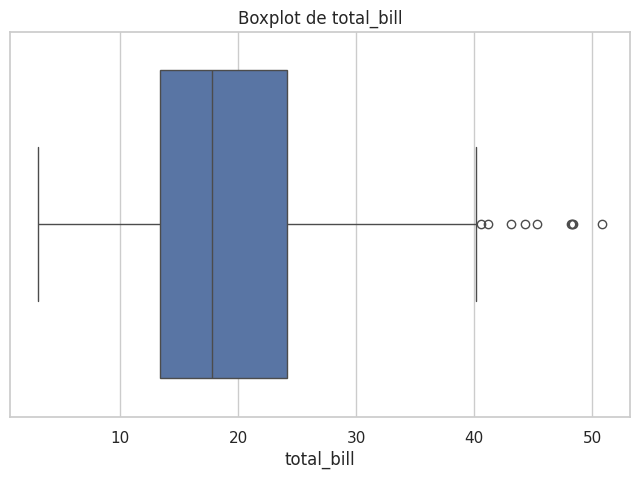

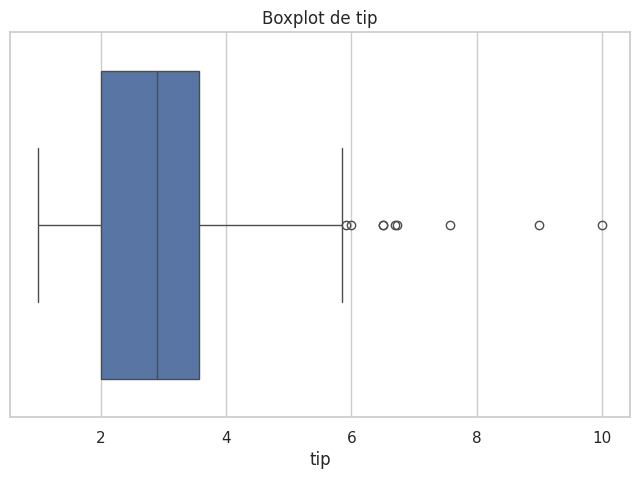

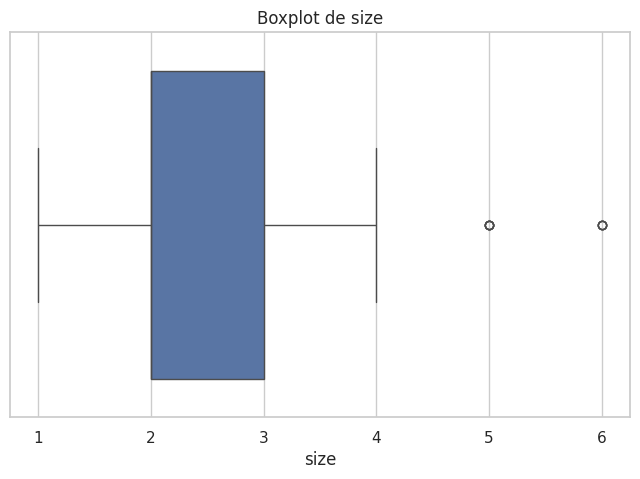

In [25]:
for col in ['total_bill', 'tip', 'size']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

## ⚖️ 7. Normalização

In [26]:
cols = ['total_bill', 'tip', 'size']

scaler_minmax = MinMaxScaler()
df_minmax = scaler_minmax.fit_transform(df[cols])

scaler_std = StandardScaler()
df_std = scaler_std.fit_transform(df[cols])

print(df_minmax[:5])
print(df_std[:5])

[[0.29157939 0.00111111 0.2       ]
 [0.1522832  0.07333333 0.4       ]
 [0.3757855  0.27777778 0.4       ]
 [0.43171345 0.25666667 0.2       ]
 [0.45077503 0.29       0.6       ]]
[[-0.31471131 -1.43994695 -0.60019263]
 [-1.06323531 -0.96920534  0.45338292]
 [ 0.1377799   0.36335554  0.45338292]
 [ 0.4383151   0.22575414 -0.60019263]
 [ 0.5407447   0.4430195   1.50695847]]


## 🏁 Conclusão

A análise revelou padrões claros entre valor da conta e gorjeta, além da presença de outliers e leve assimetria nas distribuições.